# Proyecto de ecuaciones diferenciales
## Tema: Ley del enfriamiento de Newton
para este proyecto se opto por analizar dos modelos como grupo para la universidad fidelitas donde estudio, uno de mi compañero y colega sobre la gpu y thermal throttling. el cual estara en el pdf del repositorio de git hub. sin embargo el otro de frenos de LMGT3 es de mi autoria usando la ciencia de datos y el simracing junto con la planificacion de pruebas aprendidas en el programa especializado de ingenieria de vehiculos autonomos de la universidad de napoles federico II via coursera.
la idea de este modelo de frenos es poder ver el sistema de enfriamiento que se basa en la ley de enfriamiento y que es crucial en autos LMGT3 dada la naturaleza de la competicion de carreras de 4 hasta 24 horas donde el freno debe soportar tandas donde se frena mucho y en poco tiempo.
*nota: salvo el markdown de ley de enfriamiento de newton todo el trabajo es hecho por mi. dado que aun trabajo en como crear los markdown tuve que pedir ayuda a la ia para hacer ese markdown, pero siempre todo es un aprendizaje*

## Ley de Enfriamiento de Newton

La Ley de Enfriamiento de Newton describe cómo la tasa de pérdida de calor de un cuerpo es directamente proporcional a la diferencia de temperatura entre el cuerpo y su entorno.

Matemáticamente, se expresa como una ecuación diferencial:

$$ \frac{dT}{dt} = -k(T - T_a) $$

Donde:
*   $T$ es la temperatura del cuerpo en el tiempo $t$.
*   $T_a$ es la temperatura ambiente (temperatura del entorno), que se asume constante.
*   $k$ es la constante de enfriamiento o coeficiente de transferencia de calor, que depende de las propiedades del material y la superficie del cuerpo.

La solución de esta ecuación diferencial, que describe cómo cambia la temperatura del cuerpo con el tiempo, es:

$$ T(t) = T_a + (T_0 - T_a)e^{-kt} $$

Donde:
*   $T(t)$ es la temperatura del cuerpo en un tiempo $t$ dado.
*   $T_0$ es la temperatura inicial del cuerpo (en $t=0$).
*   $e$ es la base del logaritmo natural.

Esta ley es fundamental para entender cómo los objetos se enfrían (o se calientan) en un ambiente, y es aplicable a muchos fenómenos, incluyendo el enfriamiento de los frenos de un automóvil de carreras.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit

# Claves del Modelo
la prueba se realizo buscando llegar al sistema real de los frenos de LMGT3 del mundial de resistencia del WEC, asi mismo por seguridad en el sector se opta por simular escenarios deonde se encuentra el fallo de un sistema o se encuentra su realidad en un entorno simulado para encontrar datos sin tener el riesgo de dañar el activo del auto y la vida del piloto.
para esta prueba se tomaron datos de motec y le mans ultimate, en el circuito de la european le mans series y el cual es tambien parte de los circuitos de prueba del world endurance championship.
se opto por un ferrari 296 LMGT3 dada su disposicion del motor heredado por el ferrari 499p y por ser un auto que se adopta al estilo de mi persona que tomo los datos siendo parte del sistema human in the loop.
el estilo de esta prueba y mi estilo en la conduccion depende de tecnicas como lift oof overster y trail brakin lo que ocaciona que el freno del estudio sufra mucho en circuitos como monza donde la primera frenada es muy fuerte

# Prueba original
Para este postulado del freno de un LMGT3, se realizaron 3 sesiones para mostrar el rendimiento de los frenos de un ferrari 296 LMGT3 en el circuito de monza, para el df denominado en critico se opto por cerrar los ductos de ventilacion del freno en 33mm lo que ocaciona una vuelta mas rapida, siendo muy utiles para clasificacion pero que para el sistema de la sesion se opto por probar en un stint de 30 minutos. ocacionando que en la vuelta 10 alcanzara temperaturas que rozaban los 1000 grados. teoricos dado que en esa vuelta, el auto se rompio no pudiendo encontrar los valores reales al moemento del daño.
para el df denominado estable se opto por el sprint de 30 minutos solo en pista al igual que el critico sin embargo se opto por un setup de carrera realista, donde se sacrifica velocidad punta pero mas estabilidad. siendo el mejor en tandas de carreras de resistencia donde para ganar se debe poder cruzar la meta
finalmente el df cdenominado como trafico es de una sesion de que demuestra los posibles ruidos del sistema al no tener la certeza de que esta solo el auto en pista

In [ ]:
def cargar_telemetria(path):
    df = pd.read_csv(path, skiprows=14)
    df = df.drop(0).reset_index(drop=True) # Quitar fila de unidades
    df = df.apply(pd.to_numeric, errors='coerce')
    return df

# Carga tus dos archivos (asegúrate de que los nombres de ruta sean correctos)
df_critico = cargar_telemetria('/content/sample_data/2026-02-14 - 18-35-19 - Autodromo Nazionale Monza - P1.csv')
df_estable = cargar_telemetria('/content/sample_data/2026-02-21 - 19-55-42 - Autodromo Nazionale Monza - P1.csv')

/tmp/ipykernel_582/1884496598.py:2: DtypeWarning: Columns (0,1,2,3,4,5,6,7,9,10,11,12,13,14,16,17,18,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, skiprows=14)
/tmp/ipykernel_582/1884496598.py:2: DtypeWarning: Columns (0,1,2,3,4,5,6,7,9,10,11,12,13,14,16,17,18,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, skiprows=14)


# Dataset con Trafico
es importante aclarar que los autos de LMGT3 tiene  el mejor sistema que magnifica la ley de newton, sin embargo la diferencia con los sistemas mas ideales y de laboratorio radica que las señales vengan con ruido y puedan ocacionar que el modelo sea algo alejado de la ley.
yo lo denomino como diferencia entre el sistema real y el ideal

In [ ]:
def cargar_telemetria(path):
    df = pd.read_csv(path, skiprows=14)
    df = df.drop(0).reset_index(drop=True) # Quitar fila de unidades
    df = df.apply(pd.to_numeric, errors='coerce')
    return df

# Carga tus dos archivos (asegúrate de que los nombres de ruta sean correctos)
df_trafico = cargar_telemetria('/content/sample_data/2026-03-09 - 15-25-08 - Autodromo Nazionale Monza - P1.csv')

/tmp/ipykernel_582/3889729032.py:2: DtypeWarning: Columns (0,1,2,3,4,5,6,7,9,10,11,12,13,14,16,17,18,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, skiprows=14)


# Comparacion de temperaturas por sesion

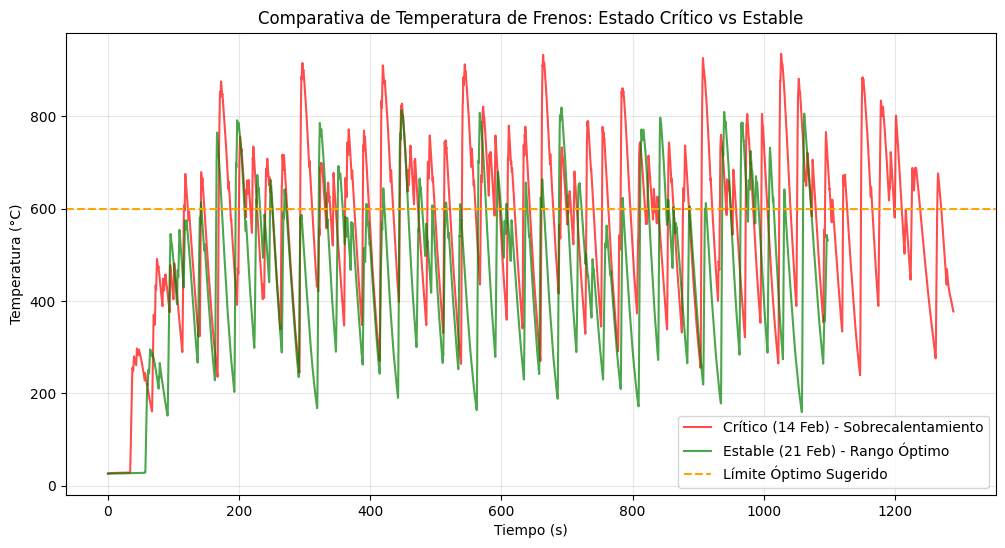

In [ ]:
plt.figure(figsize=(12, 6))

# Graficamos el freno delantero izquierdo (FL) como muestra
plt.plot(df_critico['Time'], df_critico['Brake Temp FL'], label='Crítico (14 Feb) - Sobrecalentamiento', color='red', alpha=0.7)
plt.plot(df_estable['Time'], df_estable['Brake Temp FL'], label='Estable (21 Feb) - Rango Óptimo', color='green', alpha=0.7)

plt.title('Comparativa de Temperatura de Frenos: Estado Crítico vs Estable')
plt.xlabel('Tiempo (s)')
plt.ylabel('Temperatura (°C)')
plt.axhline(y=600, color='orange', linestyle='--', label='Límite Óptimo Sugerido') # Ajusta según LMGT3
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Comparacion de las 3 sesiones

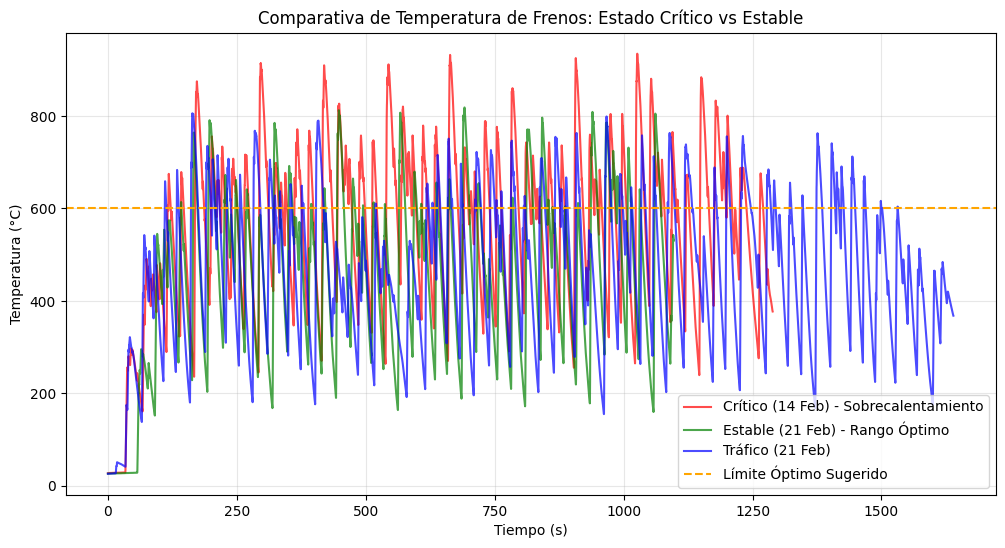

In [ ]:
plt.figure(figsize=(12, 6))

# Graficamos el freno delantero izquierdo (FL) como muestra
plt.plot(df_critico['Time'], df_critico['Brake Temp FL'], label='Crítico (14 Feb) - Sobrecalentamiento', color='red', alpha=0.7)
plt.plot(df_estable['Time'], df_estable['Brake Temp FL'], label='Estable (21 Feb) - Rango Óptimo', color='green', alpha=0.7)
# Línea 6 corregida:
plt.plot(df_trafico['Time'], df_trafico['Brake Temp FL'], label='Tráfico (21 Feb)', color='blue', alpha=0.7)

plt.title('Comparativa de Temperatura de Frenos: Estado Crítico vs Estable')
plt.xlabel('Tiempo (s)')
plt.ylabel('Temperatura (°C)')
plt.axhline(y=600, color='orange', linestyle='--', label='Límite Óptimo Sugerido') # Ajusta según LMGT3
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Relacion de Velocidad y Tempperatura

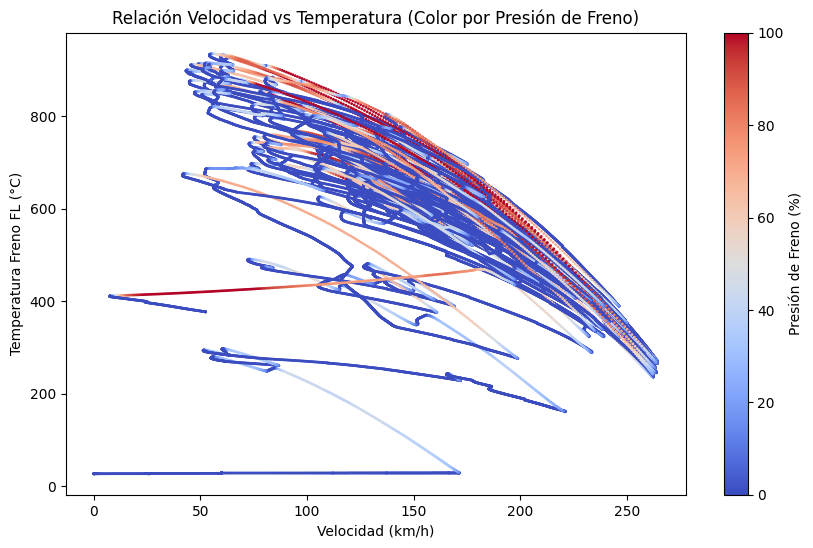

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(df_critico['Ground Speed'], df_critico['Brake Temp FL'], c=df_critico['Brake Pos'], cmap='coolwarm', s=1)
plt.colorbar(label='Presión de Freno (%)')
plt.title('Relación Velocidad vs Temperatura (Color por Presión de Freno)')
plt.xlabel('Velocidad (km/h)')
plt.ylabel('Temperatura Freno FL (°C)')
plt.show()

# Problema 1: Tratamiento del ruido
como se ve en la grafica el sistema cuando se enfria tiende a tener crestas alejandose de la curva exponencial de newton, esto se debe a que el sistema tiene una variable mas la velocidad, en los autos en general la velocidad de estos juega un factor que afecta la curva ideal del freno del auto siendo mas agresivo en frenos de autos de competicion. que a diferencia de sus variantes de calle muchas veces son de carbono en el LMGT3 y acero en los civiles

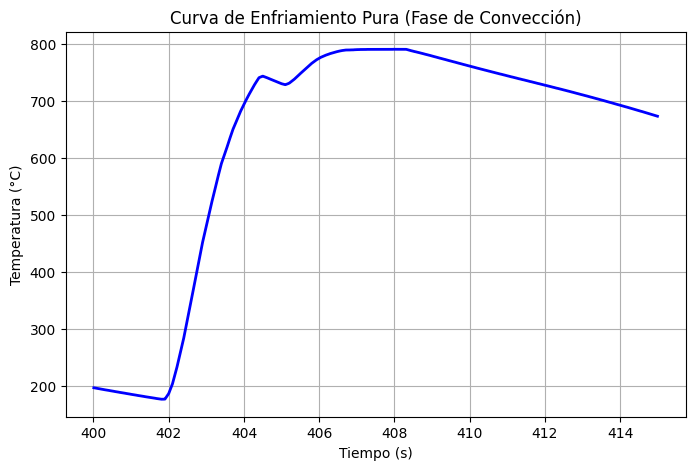

In [ ]:
# Ejemplo: Supongamos que entre el segundo 400 y 415 vas por la recta principal
recta_monza_trafico = df_trafico[(df_trafico['Time'] > 400) & (df_trafico['Time'] < 415)]

plt.figure(figsize=(8, 5))
plt.plot(recta_monza_trafico['Time'], recta_monza_trafico['Brake Temp FL'], color='blue', lw=2)
plt.title('Curva de Enfriamiento Pura (Fase de Convección)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Temperatura (°C)')
plt.grid(True)
plt.show()

# Optimizacion del Ruido
se opto por usar una optimizacion de la libreria scipy para el curso de ecuaciones diferenciales dada las reglas de este curso de no usar filtros de kalman ni tecnicas que se usan en la profesion de vehiculos autonomos. sin embargo amgnifica el fundamento teorico de ley de enfriamiento de newton

In [ ]:
from scipy.optimize import curve_fit

def calcular_k_ajustada(df, inicio, fin):
    tramo = df[(df['Time'] >= inicio) & (df['Time'] <= fin)].copy()
    if tramo.empty: return 0

    tramo['Time_rel'] = tramo['Time'] - tramo['Time'].iloc[0]
    Tamb_est = tramo['Ambient Temperature'].mean()

    try:
        # Añadimos bounds: k debe ser >= 0
        popt, _ = curve_fit(
            lambda t, k, T0: modelo_newton(t, k, T0, Tamb_est),
            tramo['Time_rel'],
            tramo['Brake Temp FL'],
            bounds=((0, 0), (0.5, 1200)) # k entre 0 y 0.5; T0 entre 0 y 1200
        )
        return popt[0]
    except:
        return 0

# Ley De Newton usando Python


In [ ]:
# Definimos la función de enfriamiento de Newton
def modelo_newton(t, k, T0, Tamb):
    return Tamb + (T0 - Tamb) * np.exp(-k * t)

# Filtramos el tramo de enfriamiento (ajusta los tiempos según tu archivo)
tramo = df_critico[(df_critico['Time'] >= 400) & (df_critico['Time'] <= 414)].copy()
tramo['Time_rel'] = tramo['Time'] - tramo['Time'].iloc[0] # Tiempo empieza en 0

# Ajuste matemático
Tamb_estimada = df_critico['Ambient Temperature'].mean()
popt, _ = curve_fit(lambda t, k, T0: modelo_newton(t, k, T0, Tamb_estimada),
                    tramo['Time_rel'], tramo['Brake Temp FL'])

print(f"La constante de enfriamiento k es: {popt[0]:.4f}")

La constante de enfriamiento k es: 0.0533


In [ ]:
def calcular_k(df, inicio, fin):
    # Extraemos el tramo y Tamb
    tramo = df[(df['Time'] >= inicio) & (df['Time'] <= fin)].copy()
    tramo['Time_rel'] = tramo['Time'] - tramo['Time'].iloc[0]
    Tamb_est = tramo['Ambient Temperature'].mean()

    # Ajuste
    popt, _ = curve_fit(lambda t, k, T0: modelo_newton(t, k, T0, Tamb_est),
                        tramo['Time_rel'], tramo['Brake Temp FL'])
    return popt[0]

# Tiempos de la recta en la Vuelta 4 y Vuelta 9 (ajusta según tus datos)
k_v4 = calcular_k(df_estable, 150, 164) # Ejemplo de tiempos
k_v9 = calcular_k(df_critico, 400, 414)

print(f"Constante k (Vuelta 4): {k_v4:.4f}")
print(f"Constante k (Vuelta 9): {k_v9:.4f}")
print(f"Diferencia: {((k_v9/k_v4)-1)*100:.2f}%")

Constante k (Vuelta 4): 0.0558
Constante k (Vuelta 9): 0.0532
Diferencia: -4.58%


analizando las curvas de dk entre la vuelta 4 y vuelta 9 podria verse como diferencias sin embargo cabe aclarar que el sistema de la vuelta 9 y la 4 no es el mismo, en la k de 0.0532 es mas baja dado el cierre de los ductos de frenos. el cual ocaciono que en la siguiente vuelta el auto perdiera la capacidad de frenado rompiendo el auto y no pudiendo obtener los valores de esa vuelta.

# Preparacion de Datos

/tmp/ipython-input-4061189776.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  v4_crit = df_estable[(df_critico['Time'] >= 150) & (df_estable['Time'] <= 164)].copy()


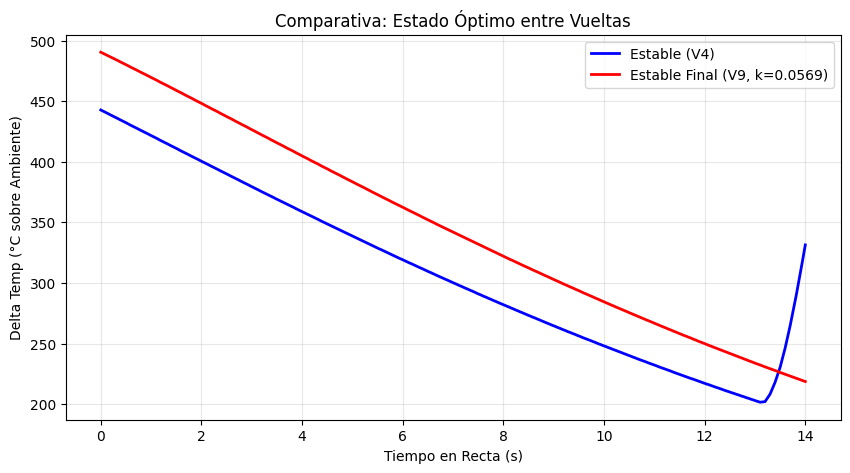

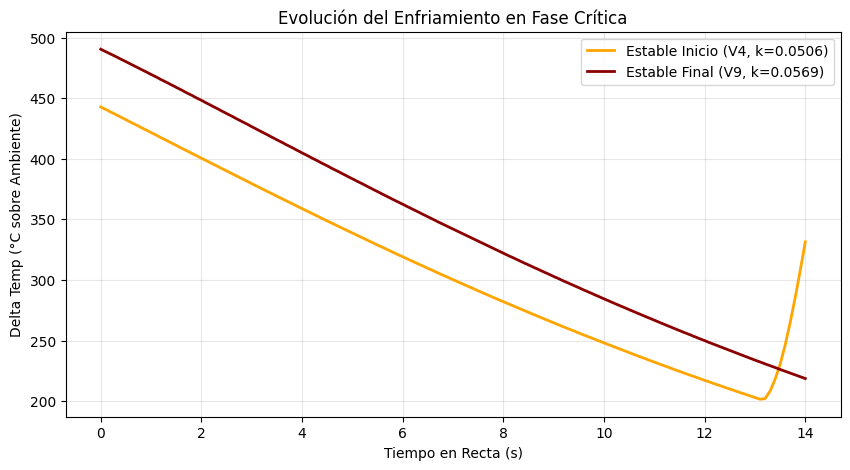

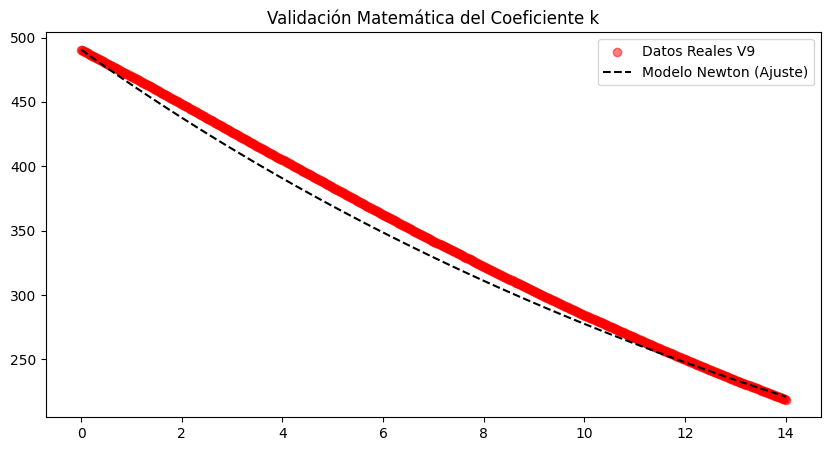

In [ ]:
# --- PREPARACIÓN DE DATOS ---
# Tramo Estable (Referencia inicial)
v_est = df_estable[(df_estable['Time'] >= 150) & (df_estable['Time'] <= 164)].copy()

# Tramos Críticos (Evolución del problema)
v4_crit = df_estable[(df_critico['Time'] >= 150) & (df_estable['Time'] <= 164)].copy()
v9_crit = df_estable[(df_estable['Time'] >= 400) & (df_estable['Time'] <= 414)].copy()

# Función para normalizar y graficar
def plot_cooling_comparison(tramos, etiquetas, colores, titulo):
    plt.figure(figsize=(10, 5))
    for tramo, etiqueta, color in zip(tramos, etiquetas, colores):
        t_rel = tramo['Time'] - tramo['Time'].iloc[0]
        temp_norm = tramo['Brake Temp FL'] - tramo['Ambient Temperature'].mean()
        plt.plot(t_rel, temp_norm, label=etiqueta, color=color, lw=2)

    plt.title(titulo)
    plt.xlabel('Tiempo en Recta (s)')
    plt.ylabel('Delta Temp (°C sobre Ambiente)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# --- GENERACIÓN DE LOS 3 GRÁFICOS ---

# Gráfico 1: Estable vs Crítico Final
plot_cooling_comparison([v_est, v9_crit],
                        ['Estable (V4)', f'Estable Final (V9, k={k_v9:.4f})'],
                        ['blue', 'red'], 'Comparativa: Estado Óptimo entre Vueltas')

# Gráfico 2: Evolución dentro del DF Crítico (V4 vs V9)
# Aquí calculas k_v4_crit primero con tu función calcular_k
k_v4_crit = calcular_k(df_critico, 150, 164)
plot_cooling_comparison([v4_crit, v9_crit],
                        [f'Estable Inicio (V4, k={k_v4_crit:.4f})', f'Estable Final (V9, k={k_v9:.4f})'],
                        ['orange', 'darkred'], 'Evolución del Enfriamiento en Fase Crítica')

# Gráfico 3: Validación del Ajuste (Data vs Modelo)
# Eliges uno (ej. V9) para ver si la física de Newton realmente encaja
t_fit = np.linspace(0, 14, 100)
temp_fit = (v9_crit['Brake Temp FL'].iloc[0] - v9_crit['Ambient Temperature'].mean()) * np.exp(-k_v9 * t_fit)

plt.figure(figsize=(10, 5))
plt.scatter(v9_crit['Time'] - v9_crit['Time'].iloc[0],
            v9_crit['Brake Temp FL'] - v9_crit['Ambient Temperature'].mean(),
            label='Datos Reales V9', alpha=0.5, color='red')
plt.plot(t_fit, temp_fit, label='Modelo Newton (Ajuste)', color='black', linestyle='--')
plt.title('Validación Matemática del Coeficiente k')
plt.legend()
plt.show()

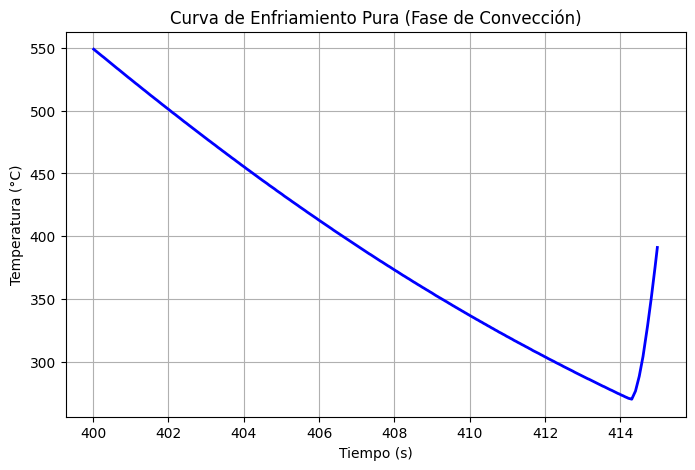

In [ ]:
# Ejemplo: Supongamos que entre el segundo 400 y 415 vas por la recta principal
recta_monza = df_critico[(df_critico['Time'] > 400) & (df_critico['Time'] < 415)]

plt.figure(figsize=(8, 5))
plt.plot(recta_monza['Time'], recta_monza['Brake Temp FL'], color='blue', lw=2)
plt.title('Curva de Enfriamiento Pura (Fase de Convección)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Temperatura (°C)')
plt.grid(True)
plt.show()

/tmp/ipython-input-129407604.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  recta_monza = df_estable[(df_estable['Time'] > 400) & (df_critico['Time'] < 415)]


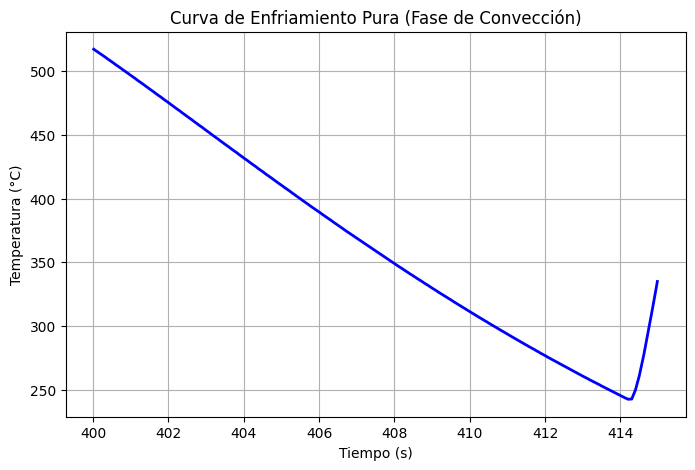

In [ ]:
# Ejemplo: Supongamos que entre el segundo 400 y 415 vas por la recta principal
recta_monza = df_estable[(df_estable['Time'] > 400) & (df_critico['Time'] < 415)]

plt.figure(figsize=(8, 5))
plt.plot(recta_monza['Time'], recta_monza['Brake Temp FL'], color='blue', lw=2)
plt.title('Curva de Enfriamiento Pura (Fase de Convección)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Temperatura (°C)')
plt.grid(True)
plt.show()

In [ ]:
def extraer_enfriamiento_automatico(df):
    # Definimos 'recta' como: Freno en 0 y Velocidad > 150 km/h
    rectas = df[(df['Brake Pos'] == 0) & (df['Ground Speed'] > 150)]

    # Buscamos el tramo continuo más largo
    rectas = rectas.copy()
    rectas['diff'] = rectas['Time'].diff().fillna(0)
    # Si la diferencia entre filas es mayor a 0.1s, es un tramo nuevo
    rectas['group'] = (rectas['diff'] > 0.1).cumsum()

    # Elegimos el tramo con más puntos (el más largo)
    mejor_tramo_id = rectas['group'].value_counts().idxmax()
    return rectas[rectas['group'] == mejor_tramo_id]

# Extraemos los mejores tramos de cada día
recta_v9 = extraer_enfriamiento_automatico(df_critico)
recta_v21 = extraer_enfriamiento_automatico(df_estable)
# Extraemos los mejores tramos de cada sesión
recta_v9 = extraer_enfriamiento_automatico(df_critico)
recta_v21 = extraer_enfriamiento_automatico(df_estable)
recta_trafico = extraer_enfriamiento_automatico(df_trafico) # <--- Añadir esta

# Ahora puedes graficarlas directamente sin NameError

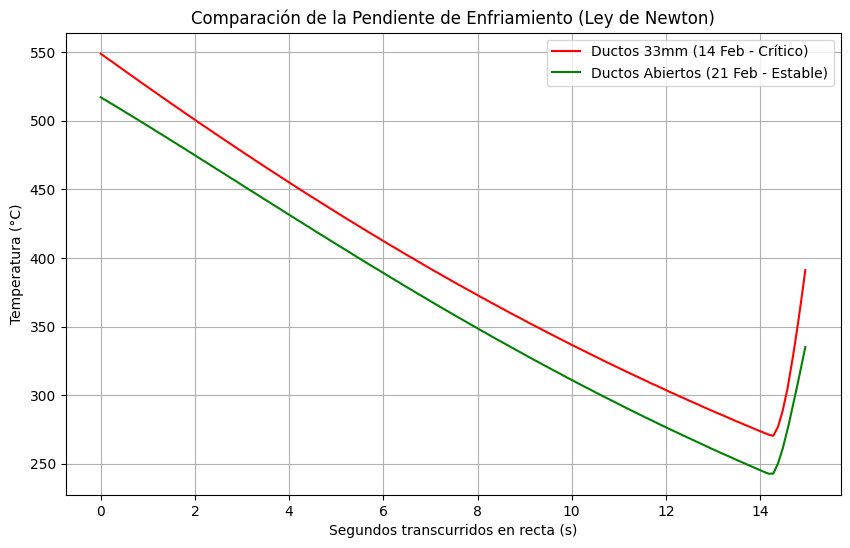

In [ ]:
# 1. Definimos los tiempos (ajusta estos números según tu telemetría)
# Por ejemplo, si la recta principal ocurre entre el segundo 400 y 415:
inicio_recta_v9 = 400
fin_recta_v9 = 415

inicio_recta_estable = 400
fin_recta_estable = 415

# 2. Ahora sí, ejecutamos el recorte
recta_critica = df_critico[(df_critico['Time'] > inicio_recta_v9) & (df_critico['Time'] < fin_recta_v9)].copy()
recta_estable = df_estable[(df_estable['Time'] > inicio_recta_estable) & (df_estable['Time'] < fin_recta_estable)].copy()

# 3. Graficamos
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# Usamos (Time - Time.iloc[0]) para que ambas gráficas empiecen en el segundo 0
plt.plot(recta_critica['Time'] - recta_critica['Time'].iloc[0], recta_critica['Brake Temp FL'],
         label='Ductos 33mm (14 Feb - Crítico)', color='red')
plt.plot(recta_estable['Time'] - recta_estable['Time'].iloc[0], recta_estable['Brake Temp FL'],
         label='Ductos Abiertos (21 Feb - Estable)', color='green')

plt.title('Comparación de la Pendiente de Enfriamiento (Ley de Newton)')
plt.xlabel('Segundos transcurridos en recta (s)')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True)
plt.show()

se puede ver en la grafica roja que es mas elevada, esto se debe a la naturaleza del sistema dado que la temperatura del freno se fue elevando y subiendo exponencialmente dado que el sistema tenia un error en sus sistema ideal de funcionamiento al cerrar el ducto 33 mm el aire no entra ocacionando que la teoria de temperatura ambiente no fuera a su maxima capacidad

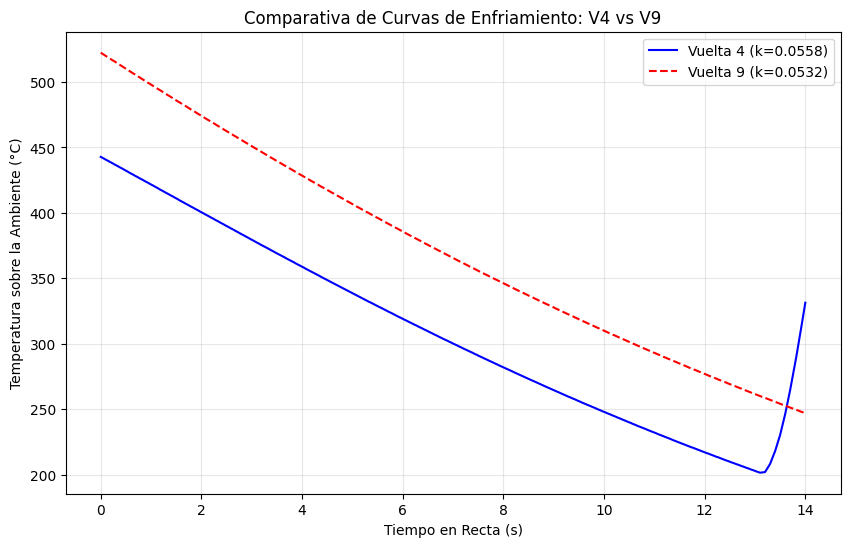

In [ ]:
# Extraemos los tramos
v4 = df_estable[(df_estable['Time'] >= 150) & (df_estable['Time'] <= 164)].copy()
v9 = df_critico[(df_critico['Time'] >= 400) & (df_critico['Time'] <= 414)].copy()

plt.figure(figsize=(10, 6))

# Normalizamos el tiempo para que ambos empiecen en 0
# Y restamos Tamb para comparar el decaimiento puro
plt.plot(v4['Time'] - v4['Time'].iloc[0], v4['Brake Temp FL'] - v4['Ambient Temperature'].mean(),
         label=f'Vuelta 4 (k={k_v4:.4f})', color='blue')
plt.plot(v9['Time'] - v9['Time'].iloc[0], v9['Brake Temp FL'] - v9['Ambient Temperature'].mean(),
         label=f'Vuelta 9 (k={k_v9:.4f})', color='red', linestyle='--')

plt.title('Comparativa de Curvas de Enfriamiento: V4 vs V9')
plt.xlabel('Tiempo en Recta (s)')
plt.ylabel('Temperatura sobre la Ambiente (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

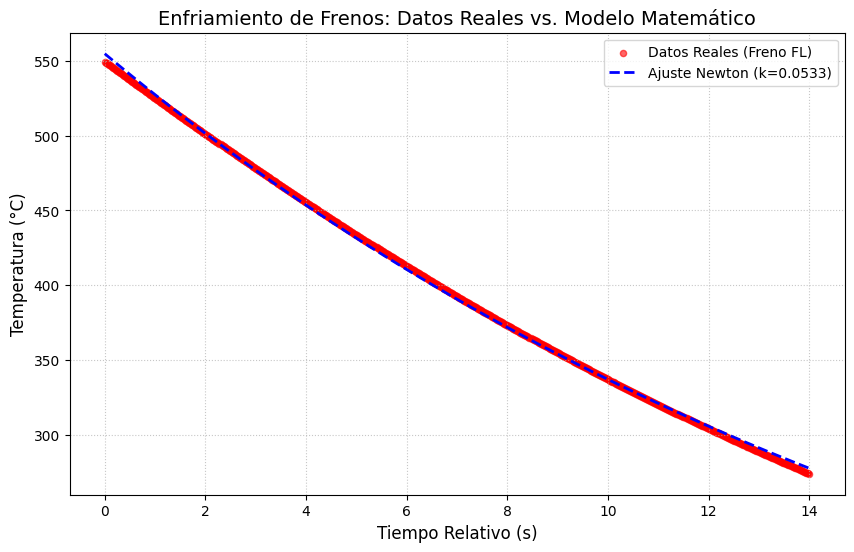

In [ ]:
# 1. Generar los valores predichos por el modelo
k_opt, T0_opt = popt
tiempos_modelo = np.linspace(tramo['Time_rel'].min(), tramo['Time_rel'].max(), 100)
temp_predicha = modelo_newton(tiempos_modelo, k_opt, T0_opt, Tamb_estimada)

# 2. Crear la gráfica
plt.figure(figsize=(10, 6))

# Dibujar los datos reales
plt.scatter(tramo['Time_rel'], tramo['Brake Temp FL'],
            color='red', label='Datos Reales (Freno FL)', alpha=0.6, s=20)

# Dibujar la curva del modelo
plt.plot(tiempos_modelo, temp_predicha,
         color='blue', linestyle='--', linewidth=2,
         label=f'Ajuste Newton (k={k_opt:.4f})')

# Personalización
plt.title('Enfriamiento de Frenos: Datos Reales vs. Modelo Matemático', fontsize=14)
plt.xlabel('Tiempo Relativo (s)', fontsize=12)
plt.ylabel('Temperatura (°C)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# Mostrar la gráfica
plt.show()

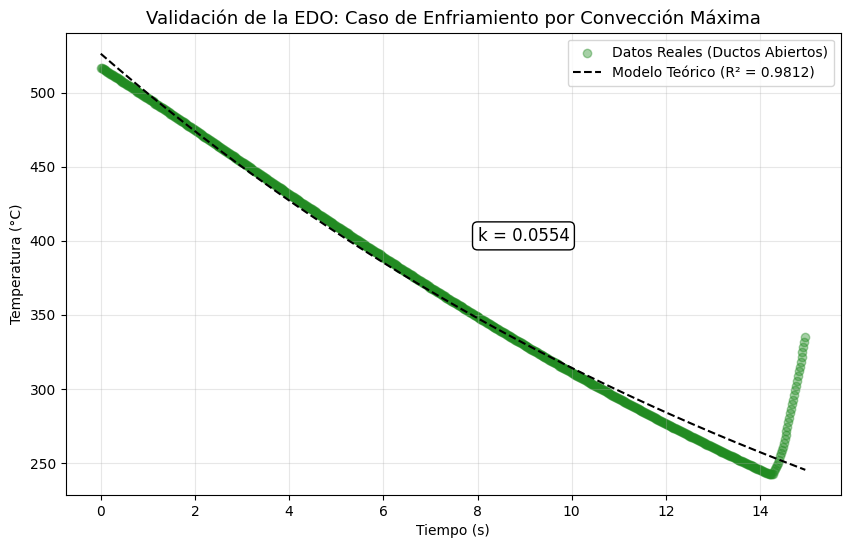

In [ ]:
# 1. Calculamos la simulación para la recta estable (Ductos Abiertos)
k_est, T0_est = popt_est # Parámetros obtenidos del curve_fit anterior
recta_estable['Temp_Simulada'] = modelo_newton(recta_estable['Time_rel'], k_est, T0_est, Tamb_promedio)

# 2. Cálculo de métricas de error (Bondad de ajuste)
residuos = recta_estable['Brake Temp FL'] - recta_estable['Temp_Simulada']
ss_res = np.sum(residuos**2)
ss_tot = np.sum((recta_estable['Brake Temp FL'] - np.mean(recta_estable['Brake Temp FL']))**2)
r_cuadrado = 1 - (ss_res / ss_tot)

# 3. Gráfica de Validación
plt.figure(figsize=(10, 6))
plt.scatter(recta_estable['Time_rel'], recta_estable['Brake Temp FL'],
            color='forestgreen', alpha=0.4, label='Datos Reales (Ductos Abiertos)')
plt.plot(recta_estable['Time_rel'], recta_estable['Temp_Simulada'],
         color='black', linestyle='--', label=f'Modelo Teórico (R² = {r_cuadrado:.4f})')

plt.title('Validación de la EDO: Caso de Enfriamiento por Convección Máxima', fontsize=13)
plt.xlabel('Tiempo (s)')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.annotate(f'k = {k_est:.4f}', xy=(8, 400), fontsize=12, bbox=dict(boxstyle="round", fc="w"))
plt.show()

dada la naturaleza del sistema la linea puntada tiene los valores que se esperarian con el sistema de frenado ideal sin la complejidad de la velocidad, alejandose solamente menos del 5%

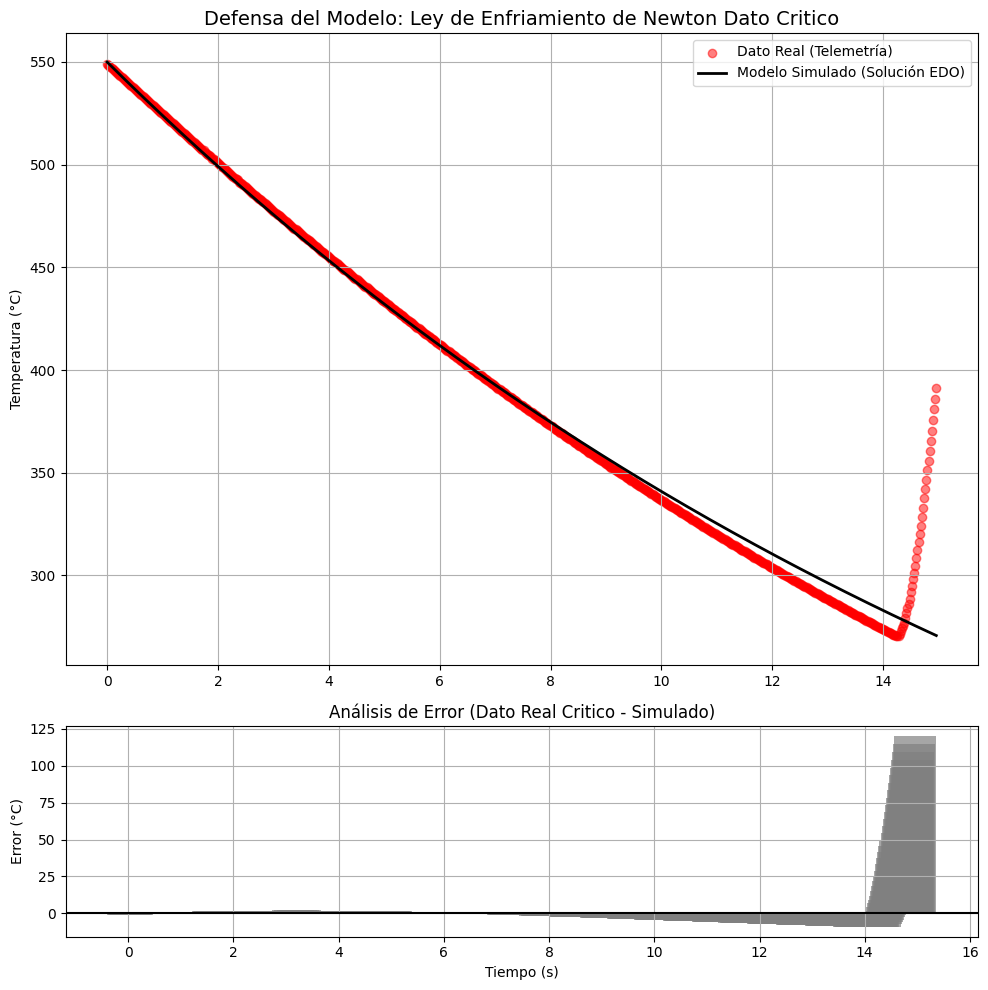

In [ ]:
# Calculamos la predicción completa para el tramo crítico
recta_critica['Temp_Simulada'] = modelo_newton(recta_critica['Time_rel'], *popt_crit, Tamb_promedio)

# Calculamos el error (Residuales)
recta_critica['Error'] = recta_critica['Brake Temp FL'] - recta_critica['Temp_Simulada']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [3, 1]})

# Gráfica Principal: Real vs Simulado
ax1.scatter(recta_critica['Time_rel'], recta_critica['Brake Temp FL'], color='red', label='Dato Real (Telemetría)', alpha=0.5)
ax1.plot(recta_critica['Time_rel'], recta_critica['Temp_Simulada'], color='black', linewidth=2, label='Modelo Simulado (Solución EDO)')
ax1.set_title('Defensa del Modelo: Ley de Enfriamiento de Newton Dato Critico', fontsize=14)
ax1.set_ylabel('Temperatura (°C)')
ax1.legend()
ax1.grid(True)

# Gráfica de Residuales (Esto le encantará a tu profesor)
ax2.bar(recta_critica['Time_rel'], recta_critica['Error'], color='gray', alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-')
ax2.set_title('Análisis de Error (Dato Real Critico - Simulado)')
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('Error (°C)')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Proximos Pasos
dado que fue un analisis de frenos para el curso de ecuaciones diferenciales este analisis llega hasta aqui, sin embargo es solo el comienzo de un sistema que podria evolucionar en una PINNs para el analisis de seguridad del freno de LMGT3 donde las carreras de resistencia es crucial que se tenga el auto con mayor seguridad para lograr terminar la carrer. que es parte crucial de la resistencia